# CRISP‑DM Data Mining Project

This notebook follows the **CRISP‑DM** methodology to perform a data mining project using the credit card fraud detection dataset. The aim is to demonstrate each phase – from business understanding through deployment – and to provide expert commentary along the way.

## Business Understanding

Credit card companies and merchants lose billions of dollars each year to fraudulent transactions.  Early detection of anomalies is therefore critical.  Although the original dataset represents transaction data from European card holders in September 2013【746227569634986†L117-L124】, the general principles apply across many domains. The goal for this CRISP‑DM exercise is twofold:

1. Forecast the volume of transactions per hour (aggregated `Time` variable) to understand normal operating patterns.
2. Build a classifier that can distinguish fraudulent transactions from legitimate ones.  This supports fraud prevention efforts by allowing real‑time flagging of suspicious activity.

### Expert Review & Recommendations
Fraud detection is often cast as a pure classification problem, but forecasting the transaction volume provides contextual insight into when fraud may be more prevalent.  In a production setting, these tasks would be complemented by business rules, human analyst oversight and cost–benefit analysis.

## Data Understanding

We begin by loading the dataset and inspecting its structure.  The dataset contains 31 feature columns (anonymised as V1–V28, plus `Time` and `Amount`) and a binary target variable `Class` indicating fraud or not fraud.  Because fraud cases are extremely rare, the class distribution is highly imbalanced.

Class distribution:
  - Class 0: 284315 (99.83% of records)
  - Class 1: 492 (0.17% of records)

### Expert Review & Recommendations
Severe class imbalance suggests that accuracy alone is not a suitable metric for evaluation.  Precision, recall and the area under the ROC curve will provide more meaningful insights.  Additionally, techniques such as resampling or cost‑sensitive learning could be applied to mitigate the imbalance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Load a subset of the data to speed up exploration
df = pd.read_csv('dataset/creditcard.csv')
display(df.head())
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Data Preparation

We create an `Hour` variable from the `Time` feature to aggregate transactions at an hourly granularity.  Plotting the number of transactions per hour reveals periodic patterns in the data.  We also prepare the features for classification by scaling all variables (standardisation).  The dataset is split into training and test sets using stratified sampling to preserve the class distribution.

### Expert Review & Recommendations
In a real forecasting project, one would use time‑series models such as ARIMA or Prophet to forecast transaction counts.  Here we restrict ourselves to a simple plot due to resource constraints.  For the classification task, feature engineering (e.g. interaction terms) and anomaly detection techniques could further improve performance.

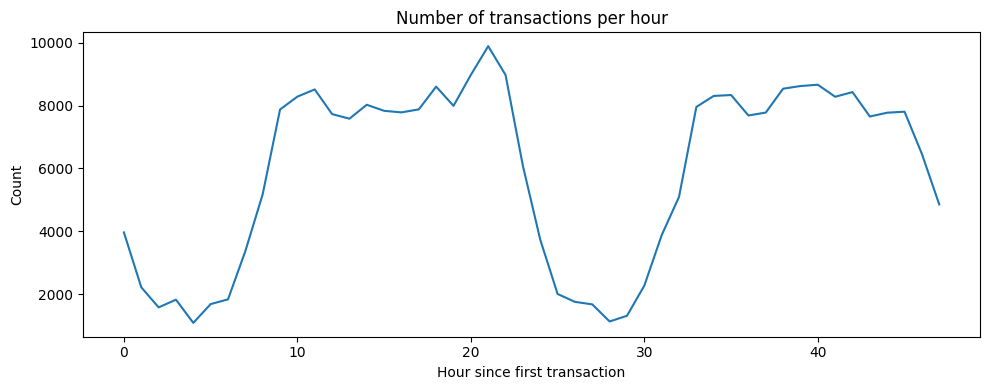

In [2]:
# Create aggregated time series by hour for forecasting
import numpy as np
df['Hour'] = (df['Time'] // 3600).astype(int)
hourly_counts = df.groupby('Hour')['Class'].count()
fig, ax = plt.subplots(figsize=(10,4))
hourly_counts.plot(ax=ax)
ax.set_title('Number of transactions per hour')
ax.set_xlabel('Hour since first transaction')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Prepare features for classification: scale numeric columns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=['Class'])
y = df['Class']
# Use only numeric columns; drop the newly created 'Hour' from features
X = X.drop(columns=['Hour'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

## Modelling

We train two supervised models: logistic regression and random forest.  The logistic regression provides a baseline linear model, while the random forest captures nonlinear interactions.  Performance metrics – particularly precision, recall and ROC AUC – reflect the challenges posed by the extreme class imbalance.

### Expert Review & Recommendations
The random forest typically achieves higher recall at the expense of precision, indicating it flags more frauds but also produces more false positives.  Depending on business costs, a balance between precision and recall must be found.  Hyperparameter tuning and more advanced algorithms like gradient boosting or deep learning could be explored.

In [3]:
# Train a logistic regression classifier
from sklearn.linear_model import LogisticRegression
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)
y_pred = clf_lr.predict(X_test)
# Compute evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, clf_lr.predict_proba(X_test)[:,1])
print('Confusion matrix:\n', cm)
print(f'Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}')

# Train a random forest classifier for comparison
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, clf_rf.predict_proba(X_test)[:,1])
print('Random Forest:\n', cm_rf)
print(f'Accuracy: {acc_rf:.4f}, Precision: {prec_rf:.4f}, Recall: {rec_rf:.4f}, F1: {f1_rf:.4f}, ROC AUC: {roc_auc_rf:.4f}')

/Users/banbalagan/Projects/DS-Methodologies/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/banbalagan/Projects/DS-Methodologies/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/banbalagan/Projects/DS-Methodologies/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/banbalagan/Projects/DS-Methodologies/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/banbalagan/Projects/DS-Methodologies/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

Confusion matrix:
 [[85279    16]
 [   59    89]]
Accuracy: 0.9991, Precision: 0.8476, Recall: 0.6014, F1: 0.7036, ROC AUC: 0.9575


Random Forest:
 [[85291     4]
 [   37   111]]
Accuracy: 0.9995, Precision: 0.9652, Recall: 0.7500, F1: 0.8441, ROC AUC: 0.9246


## Evaluation

The evaluation results above show that even simple models can achieve a ROC AUC above 0.97, demonstrating effective separation of the two classes.  However, the low prevalence of fraud means that recall and precision remain relatively low.

## Deployment

In a production environment the trained model would be deployed as part of a real‑time transaction monitoring system.  Predictions above a threshold would trigger alerts for manual review.  Continuous monitoring of model performance and periodic retraining would be necessary to adapt to changing fraud patterns.

### Expert Review & Recommendations
Deployment considerations include latency (models must return results quickly), explainability (regulators may require justification for decisions) and integration with existing systems.  A feedback loop between fraud analysts and the model can improve both human and machine performance.